X shape: (1797, 64)
y shape: (1797,)


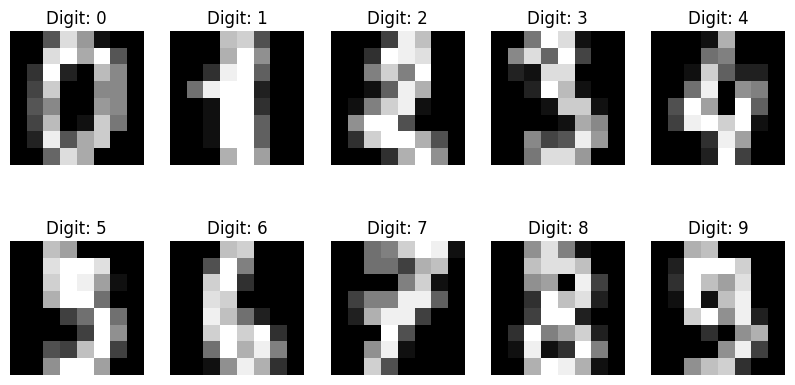

Training data: (1437, 64)
Testing data: (360, 64)

SVM Accuracy: 0.9805555555555555

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


Confusion Matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  1  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  

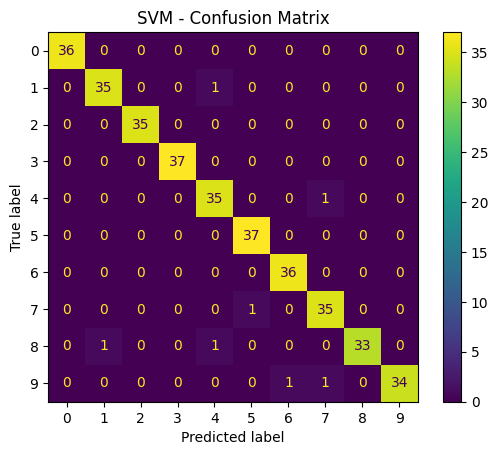

In [ ]:
# ==========================================
# HANDWRITTEN DIGIT RECOGNITION USING SVM
# ==========================================

# 1. Import libraries
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# 2. Load the dataset
digits = load_digits()

X = digits.data
y = digits.target


# 3. Display dataset shape
print("X shape:", X.shape)
print("y shape:", y.shape)


# 4. Display some images
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Digit: {digits.target[i]}")
    plt.axis("off")

plt.show()


# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


# 6. Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 7. Create SVM model
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


# 8. Train the model
svm_model.fit(X_train_scaled, y_train)


# 9. Make predictions
y_pred = svm_model.predict(X_test_scaled)


# 10. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nSVM Accuracy:", accuracy)


# 11. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 12. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# 13. Display Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=digits.target_names
)

disp.plot()
plt.title("SVM - Confusion Matrix")
plt.show()